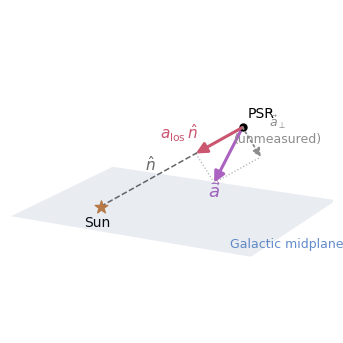

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import proj3d

C_TRUE, C_LOS, C_LOST, C_SIGHT = "#ab62c0", "#ca5670", "0.55", "0.4"

class Arrow3D(FancyArrowPatch):
    def __init__(self, p0, p1, **kw):
        super().__init__((0, 0), (0, 0), **kw)
        self._p0, self._p1 = np.asarray(p0), np.asarray(p1)
    def do_3d_projection(self, renderer=None):
        x, y, z = zip(self._p0, self._p1)
        xs, ys, zs = proj3d.proj_transform(x, y, z, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return min(zs)

def arrow(ax, p0, p1, color, lw=2.2, style="-", mut=16):
    ax.add_artist(Arrow3D(p0, p1, arrowstyle="-|>", mutation_scale=mut, lw=lw,
                          linestyle=style, color=color, shrinkA=0, shrinkB=0, zorder=5))

fig = plt.figure(figsize=(5.2, 4.2))
ax = fig.add_subplot(projection="3d")

sun = np.array([0.0, 0.0, 0.0])
psr = np.array([1.7, 0.7, 1.1])
nhat = psr / np.linalg.norm(psr)
a_true = np.array([-0.35, -0.10, -0.75])
a_los_vec = (a_true @ nhat) * nhat
a_perp = a_true - a_los_vec

gx, gy = np.meshgrid(np.linspace(-0.8, 2.6, 2), np.linspace(-0.9, 1.7, 2))
ax.plot_surface(gx, gy, np.zeros_like(gx), color="#638ccc", alpha=0.12, zorder=0)
ax.text(2.25, -0.75, 0.02, "Galactic midplane", color="#638ccc", fontsize=9)

ax.scatter(*sun, color="#c57c3c", s=90, marker="*", zorder=6)
ax.text(sun[0] - 0.05, sun[1], sun[2] - 0.28, "Sun", fontsize=10, ha="center")
ax.scatter(*psr, color="k", s=25, zorder=6)
ax.text(psr[0] + 0.07, psr[1], psr[2] + 0.14, "PSR", fontsize=10)

ax.plot(*zip(sun, psr), ls="--", lw=1.1, color=C_SIGHT, zorder=2)
mid = 0.32 * psr
ax.text(mid[0], mid[1], mid[2] + 0.14, r"$\hat{n}$", color=C_SIGHT, fontsize=11)

arrow(ax, psr, psr + a_true, C_TRUE)
ax.text(*(psr + a_true + [0.0, 0, -0.2]), r"$\vec{a}$", color=C_TRUE, fontsize=13, ha="center")
arrow(ax, psr, psr + a_los_vec, C_LOS)
ax.text(*(psr + a_los_vec + [-0.52, 0, 0.12]), r"$a_{\mathrm{los}}\,\hat{n}$",
        color=C_LOS, fontsize=11)
arrow(ax, psr, psr + a_perp, C_LOST, lw=1.4, style=":", mut=12)
ax.text(*(psr + a_perp + [0.24, 0, 0.22]), "$\\vec{a}_{\\perp}$\n(unmeasured)",
        color=C_LOST, fontsize=9, ha="center")
ax.plot(*zip(psr + a_true, psr + a_los_vec), ls=":", lw=0.9, color="0.7", zorder=1)
ax.plot(*zip(psr + a_true, psr + a_perp), ls=":", lw=0.9, color="0.7", zorder=1)

ax.set_axis_off()
ax.set_xlim(-0.6, 2.4); ax.set_ylim(-0.8, 1.6); ax.set_zlim(-0.4, 1.5)
ax.set_box_aspect((1.25, 1.0, 0.8))
ax.view_init(elev=16, azim=-62)
fig.savefig("../../../accelerations-paper/figures/los_geometry.pdf", bbox_inches="tight")


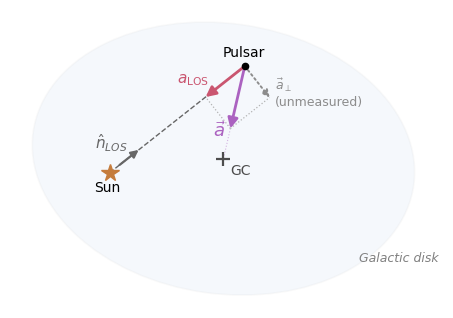

In [22]:
from matplotlib.patches import Ellipse, FancyArrowPatch

C_TRUE, C_LOS, C_LOST, C_SIGHT = "#ab62c0", "#ca5670", "0.55", "0.4"

def arrow(ax, p0, p1, color, lw=2.0, style="-", mut=15):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=mut,
                                 lw=lw, linestyle=style, color=color,
                                 shrinkA=0, shrinkB=0, zorder=5))

fig, ax = plt.subplots(figsize=(5.6, 4.0))

gc  = np.array([0.0, 0.0])
sun = np.array([-8.0, -1.0])
psr = np.array([1.5, 6.5])
nhat = (psr - sun) / np.linalg.norm(psr - sun)
a_true = 4.5 * (gc - psr) / np.linalg.norm(gc - psr)   # points at the GC
a_los_vec = (a_true @ nhat) * nhat
a_perp = a_true - a_los_vec

ax.add_patch(Ellipse(gc, width=27, height=19, angle=-8, facecolor="#638ccc",
                     alpha=0.06, edgecolor="0.65", lw=1.2, zorder=0))
ax.text(9.5, -7.2, "Galactic disk", color="0.5", fontsize=9, style="italic")

ax.plot(*gc, marker="+", color="0.3", ms=10, mew=1.6, zorder=4)
ax.text(0.5, -1.1, "GC", fontsize=10, color="0.3")
ax.plot(*sun, marker="*", color="#c57c3c", ms=13, zorder=6)
ax.text(sun[0] - 0.2, sun[1] - 1.3, "Sun", fontsize=10, ha="center")
ax.plot(*psr, marker="o", color="k", ms=4.5, zorder=6)
ax.text(psr[0] - 0.1, psr[1] + 0.7, "Pulsar", fontsize=10, ha="center")

ax.plot(*zip(sun, psr), ls="--", lw=1.0, color=C_SIGHT, zorder=2)
arrow(ax, sun + 0.9 * nhat, sun + 2.6 * nhat, C_SIGHT, lw=1.6, mut=11)
ax.text(*(sun + 1.9 * nhat + [-2.5, 0.5]), r"$\hat{n}_{LOS}$", color=C_SIGHT, fontsize=11)

arrow(ax, psr, psr + a_true, C_TRUE)
ax.text(*(psr + a_true + [-1.2, -0.55]), r"$\vec{a}$", color=C_TRUE, fontsize=13)
arrow(ax, psr, psr + a_los_vec, C_LOS)
ax.text(*(psr + a_los_vec + [-2, 1]), r"$a_{\mathrm{LOS}}$",
        color=C_LOS, fontsize=11)
arrow(ax, psr, psr + a_perp, C_LOST, lw=1.4, style=":", mut=11)
ax.text(*(psr + a_perp + [0.35, -0.55]), "$\\vec{a}_{\\perp}$\n(unmeasured)",
        color=C_LOST, fontsize=9)

ax.plot(*zip(psr + a_true, gc), ls=":", lw=0.8, color=C_TRUE, alpha=0.45, zorder=1)
ax.plot(*zip(psr + a_true, psr + a_los_vec), ls=":", lw=0.9, color="0.7", zorder=1)
ax.plot(*zip(psr + a_true, psr + a_perp), ls=":", lw=0.9, color="0.7", zorder=1)

ax.set_xlim(-15, 15.5); ax.set_ylim(-10.5, 10.5)
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig("../../../accelerations-paper/figures/los_geometry.pdf", bbox_inches="tight")


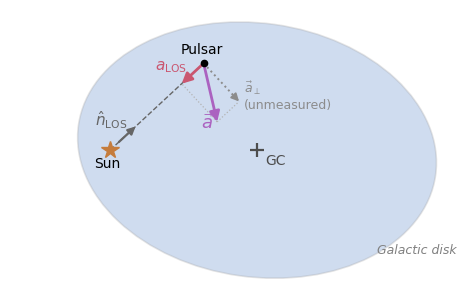

In [48]:
from matplotlib.patches import Ellipse, FancyArrowPatch

C_TRUE, C_LOS, C_LOST, C_SIGHT = "#ab62c0", "#ca5670", "0.55", "0.4"

def arrow(ax, p0, p1, color, lw=2.0, style="-", mut=15):
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    if style != "-":  # dotted shaft + solid head (FancyArrowPatch dots the head too)
        u = (p1 - p0) / np.linalg.norm(p1 - p0)
        ax.plot(*zip(p0, p1 - 0.35 * u), ls=style, lw=lw, color=color, zorder=5)
        ax.add_patch(FancyArrowPatch(p1 - 0.5 * u, p1, arrowstyle="-|>",
                                     mutation_scale=mut, lw=lw, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))
    else:
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=mut,
                                     lw=lw, linestyle=style, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))

fig, ax = plt.subplots(figsize=(5.6, 4.0))

gc  = np.array([3.0, -2])
sun = np.array([-8.0, -2.0])
psr = np.array([-1, 4.5])
nhat = (psr - sun) / np.linalg.norm(psr - sun)

a_dir = gc - psr + np.array([-2.5, 0.0])   # roughly GC-ward, deliberately not exact
a_true = 4.5 * a_dir / np.linalg.norm(a_dir)
a_los_vec = (a_true @ nhat) * nhat
a_perp = a_true - a_los_vec

ax.add_patch(Ellipse(gc, width=27, height=19, angle=-8, facecolor="#638ccc",
                     alpha=0.3, edgecolor="0.65", lw=1.2, zorder=0))
ax.text(12.0, -9.8, "Galactic disk", color="0.5", fontsize=9, style="italic")

ax.plot(*gc, marker="+", color="0.3", ms=10, mew=1.6, zorder=4)
ax.text(gc[0] + 0.6, gc[1] - 1.1, "GC", fontsize=10, color="0.3")
ax.plot(*sun, marker="*", color="#c57c3c", ms=13, zorder=6)
ax.text(sun[0] - 0.2, sun[1] - 1.3, "Sun", fontsize=10, ha="center")
ax.plot(*psr, marker="o", color="k", ms=4.5, zorder=6)
ax.text(psr[0] - 0.1, psr[1] + 0.7, "Pulsar", fontsize=10, ha="center")

ax.plot(*zip(sun, psr), ls="--", lw=1.0, color=C_SIGHT, zorder=2)
arrow(ax, sun + 0.9 * nhat, sun + 2.6 * nhat, C_SIGHT, lw=1.6, mut=11)
ax.text(*(sun + 1.9 * nhat + [-2.5, 0.5]), r"$\hat{n}_{\rm LOS}$",
        color=C_SIGHT, fontsize=11)

arrow(ax, psr, psr + a_true, C_TRUE)
ax.text(*(psr + a_true + [-1.2, -0.55]), r"$\vec{a}$", color=C_TRUE, fontsize=13)
arrow(ax, psr, psr + a_los_vec, C_LOS)
ax.text(*(psr + a_los_vec + [-2.0, 1.0]), r"$a_{\mathrm{LOS}}$",
        color=C_LOS, fontsize=11)
arrow(ax, psr, psr + a_perp, C_LOST, lw=1.4, style=":", mut=11)
ax.text(*(psr + a_perp + [0.35, -0.55]), "$\\vec{a}_{\\perp}$\n(unmeasured)",
        color=C_LOST, fontsize=9)

ax.plot(*zip(psr + a_true, psr + a_los_vec), ls=":", lw=0.9, color="0.7", zorder=1)
ax.plot(*zip(psr + a_true, psr + a_perp), ls=":", lw=0.9, color="0.7", zorder=1)

ax.set_xlim(-15.5, 17); ax.set_ylim(-13, 8.5)
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig("../../../accelerations-paper/figures/los_geometry.pdf", bbox_inches="tight")


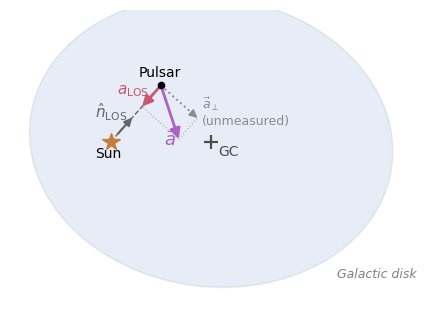

In [44]:
from matplotlib.patches import Ellipse, FancyArrowPatch

C_TRUE, C_LOS, C_LOST, C_SIGHT = "#ab62c0", "#ca5670", "0.55", "0.4"

def arrow(ax, p0, p1, color, lw=2.0, style="-", mut=15):
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    if style != "-":  # dotted shaft + solid head (FancyArrowPatch dots the head too)
        u = (p1 - p0) / np.linalg.norm(p1 - p0)
        ax.plot(*zip(p0, p1 - 0.35 * u), ls=style, lw=lw, color=color, zorder=5)
        ax.add_patch(FancyArrowPatch(p1 - 0.5 * u, p1, arrowstyle="-|>",
                                     mutation_scale=mut, lw=lw, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))
    else:
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=mut,
                                     lw=lw, linestyle=style, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))

fig, ax = plt.subplots(figsize=(5.6, 4.0), facecolor="white")

# roughly to scale: disk R ~ 14.5 kpc, Sun at 8 kpc, pulsar a few kpc away
gc  = np.array([0.0, 0.0])
sun = np.array([-8.0, 0.0])   # 8 kpc from the GC
psr = np.array([-4.0, 4.5])    # ~5 kpc from the Sun, like the catalog
nhat = (psr - sun) / np.linalg.norm(psr - sun)

a_dir = gc - psr + np.array([-2.5, 0.0])   # roughly GC-ward, deliberately not exact
a_true = 4.5 * a_dir / np.linalg.norm(a_dir)
a_los_vec = (a_true @ nhat) * nhat
a_perp = a_true - a_los_vec

ax.add_patch(Ellipse(gc, width=29, height=23, angle=-8, facecolor="#638ccc",
                     alpha=0.15, edgecolor="0.55", lw=1.2, zorder=0))
ax.text(10.0, -10.8, "Galactic disk", color="0.5", fontsize=9, style="italic")

ax.plot(*gc, marker="+", color="0.3", ms=10, mew=1.6, zorder=4)
ax.text(gc[0] + 0.6, gc[1] - 1.1, "GC", fontsize=10, color="0.3")
ax.plot(*sun, marker="*", color="#c57c3c", ms=13, zorder=6)
ax.text(sun[0] - 0.2, sun[1] - 1.3, "Sun", fontsize=10, ha="center")
ax.plot(*psr, marker="o", color="k", ms=4.5, zorder=6)
ax.text(psr[0] - 0.1, psr[1] + 0.7, "Pulsar", fontsize=10, ha="center")

ax.plot(*zip(sun, psr), ls="--", lw=1.0, color=C_SIGHT, zorder=2)
arrow(ax, sun + 0.9 * nhat, sun + 2.6 * nhat, C_SIGHT, lw=1.6, mut=11)
ax.text(*(sun + 1.9 * nhat + [-2.5, 0.5]), r"$\hat{n}_{\rm LOS}$",
        color=C_SIGHT, fontsize=11)

arrow(ax, psr, psr + a_true, C_TRUE)
ax.text(*(psr + a_true + [-1.2, -0.55]), r"$\vec{a}$", color=C_TRUE, fontsize=13)
arrow(ax, psr, psr + a_los_vec, C_LOS)
ax.text(*(psr + a_los_vec + [-2.0, 1.0]), r"$a_{\mathrm{LOS}}$",
        color=C_LOS, fontsize=11)
arrow(ax, psr, psr + a_perp, C_LOST, lw=1.4, style=":", mut=11)
ax.text(*(psr + a_perp + [0.35, -0.55]), "$\\vec{a}_{\\perp}$\n(unmeasured)",
        color=C_LOST, fontsize=9)

ax.plot(*zip(psr + a_true, psr + a_los_vec), ls=":", lw=0.9, color="0.7", zorder=1)
ax.plot(*zip(psr + a_true, psr + a_perp), ls=":", lw=0.9, color="0.7", zorder=1)

ax.set_xlim(-16, 16.5); ax.set_ylim(-14, 10.5)
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig("../../../accelerations-paper/figures/los_geometry.pdf", bbox_inches="tight")


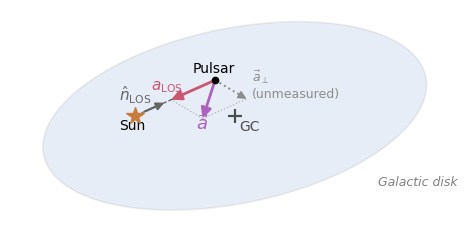

In [49]:
from matplotlib.patches import FancyArrowPatch

C_TRUE, C_LOS, C_LOST, C_SIGHT = "#ab62c0", "#ca5670", "0.55", "0.4"

TILT, SHEAR = 0.52, 0.35   # viewing inclination (y-squash) and skew

def proj(p):
    p = np.asarray(p, float)
    return np.array([p[0] + SHEAR * p[1], TILT * p[1]])

def arrow(ax, p0, p1, color, lw=2.0, style="-", mut=15):
    p0, p1 = proj(p0), proj(p1)
    if style != "-":  # dotted shaft + solid head
        u = (p1 - p0) / np.linalg.norm(p1 - p0)
        ax.plot(*zip(p0, p1 - 0.25 * u), ls=style, lw=lw, color=color, zorder=5)
        ax.add_patch(FancyArrowPatch(p1 - 0.4 * u, p1, arrowstyle="-|>",
                                     mutation_scale=mut, lw=lw, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))
    else:
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=mut,
                                     lw=lw, color=color, shrinkA=0, shrinkB=0, zorder=5))

def line(ax, p0, p1, **kw):
    ax.plot(*zip(proj(p0), proj(p1)), **kw)

fig, ax = plt.subplots(figsize=(5.8, 3.6), facecolor="white")

# --- in-plane geometry (kpc): GC at origin, roughly to scale --------------
gc  = np.array([0.0, 0.0])
sun = np.array([-8.0, 0.0])    # 8 kpc from the GC
psr = np.array([-3.5, 5.5])
nhat = (psr - sun) / np.linalg.norm(psr - sun)

a_dir = gc - psr + np.array([-2.5, 0.0])   # roughly GC-ward, deliberately not exact
a_true = 6.0 * a_dir / np.linalg.norm(a_dir)
a_los_vec = (a_true @ nhat) * nhat
a_perp = a_true - a_los_vec

# --- disk: a true circle of R = 14.5 kpc, drawn through the projection ----
th = np.linspace(0, 2 * np.pi, 200)
rim = np.array([proj(gc + 14.5 * np.array([np.cos(t), np.sin(t)])) for t in th])
ax.fill(rim[:, 0], rim[:, 1], facecolor="#638ccc", alpha=0.15,
        edgecolor="0.55", lw=1.2, zorder=0)
ax.text(11.5, -5.6, "Galactic disk", color="0.5", fontsize=9, style="italic")

# --- markers --------------------------------------------------------------
ax.plot(*proj(gc), marker="+", color="0.3", ms=10, mew=1.6, zorder=4)
ax.text(*(proj(gc) + [0.4, -1.2]), "GC", fontsize=10, color="0.3")
ax.plot(*proj(sun), marker="*", color="#c57c3c", ms=13, zorder=6)
ax.text(*(proj(sun) + [-0.2, -1.1]), "Sun", fontsize=10, ha="center")
ax.plot(*proj(psr), marker="o", color="k", ms=4.5, zorder=6)
ax.text(*(proj(psr) + [-0.1, 0.6]), "Pulsar", fontsize=10, ha="center")

# --- sight line + unit vector ---------------------------------------------
line(ax, sun, psr, ls="--", lw=1.0, color=C_SIGHT, zorder=2)
arrow(ax, sun + 0.9 * nhat, sun + 2.6 * nhat, C_SIGHT, lw=1.6, mut=11)
ax.text(*(proj(sun + 1.9 * nhat) + [-3.0, 0.45]), r"$\hat{n}_{\rm LOS}$",
        color=C_SIGHT, fontsize=11)

# --- vectors --------------------------------------------------------------
arrow(ax, psr, psr + a_true, C_TRUE)
ax.text(*(proj(psr + a_true) + [-0.55, -0.9]), r"$\vec{a}$", color=C_TRUE, fontsize=13)
arrow(ax, psr, psr + a_los_vec, C_LOS)
ax.text(*(proj(psr + a_los_vec) + [-1.6, 0.75]), r"$a_{\mathrm{LOS}}$",
        color=C_LOS, fontsize=11)
arrow(ax, psr, psr + a_perp, C_LOST, lw=1.4, style=":", mut=11)
ax.text(*(proj(psr + a_perp) + [0.45, 0.1]), "$\\vec{a}_{\\perp}$\n(unmeasured)",
        color=C_LOST, fontsize=9)

line(ax, psr + a_true, psr + a_los_vec, ls=":", lw=0.9, color="0.7", zorder=1)
line(ax, psr + a_true, psr + a_perp, ls=":", lw=0.9, color="0.7", zorder=1)

ax.set_xlim(-18, 18); ax.set_ylim(-8.5, 8.5)
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig("../../../accelerations-paper/figures/los_geometry.pdf", bbox_inches="tight")


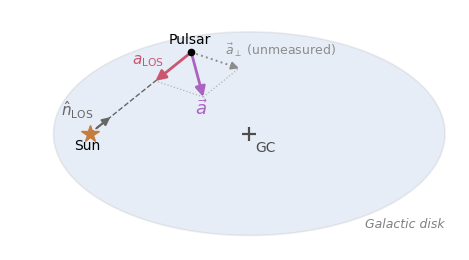

In [59]:
from matplotlib.patches import FancyArrowPatch

C_TRUE, C_LOS, C_LOST, C_SIGHT = "#ab62c0", "#ca5670", "0.55", "0.4"

TILT, SHEAR = 0.52, 0.0   # inclination only; SHEAR=0 keeps the ellipse horizontal

def proj(p):
    p = np.asarray(p, float)
    return np.array([p[0] + SHEAR * p[1], TILT * p[1]])

def arrow(ax, p0, p1, color, lw=2.0, style="-", mut=15):
    p0, p1 = proj(p0), proj(p1)
    if style != "-":  # dotted shaft + solid head
        u = (p1 - p0) / np.linalg.norm(p1 - p0)
        ax.plot(*zip(p0, p1 - 0.25 * u), ls=style, lw=lw, color=color, zorder=5)
        ax.add_patch(FancyArrowPatch(p1 - 0.4 * u, p1, arrowstyle="-|>",
                                     mutation_scale=mut, lw=lw, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))
    else:
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=mut,
                                     lw=lw, color=color, shrinkA=0, shrinkB=0, zorder=5))

def line(ax, p0, p1, **kw):
    ax.plot(*zip(proj(p0), proj(p1)), **kw)

fig, ax = plt.subplots(figsize=(5.8, 3.4), facecolor="white")

# --- in-plane geometry (kpc). y-values are screen-y / TILT so the projected
# --- layout matches the flat version's placement --------------------------
gc  = np.array([3.0, -3.8])
sun = np.array([-8.0, -3.8])
psr = np.array([-1.0, 7])
nhat = (psr - sun) / np.linalg.norm(psr - sun)

a_dir = gc - psr + np.array([-2.5, 0.0])   # roughly GC-ward, deliberately not exact
a_true = 6.0 * a_dir / np.linalg.norm(a_dir)
a_los_vec = (a_true @ nhat) * nhat
a_perp = a_true - a_los_vec

# --- disk: a true circle of R = 13.5 kpc drawn through the projection -----
th = np.linspace(0, 2 * np.pi, 200)
rim = np.array([proj(gc + 13.5 * np.array([np.cos(t), np.sin(t)])) for t in th])
ax.fill(rim[:, 0], rim[:, 1], facecolor="#638ccc", alpha=0.15,
        edgecolor="0.55", lw=1.2, zorder=0)
ax.text(11.0, -8.4, "Galactic disk", color="0.5", fontsize=9, style="italic")

ax.plot(*proj(gc), marker="+", color="0.3", ms=10, mew=1.6, zorder=4)
ax.text(*(proj(gc) + [0.4, -1.2]), "GC", fontsize=10, color="0.3")
ax.plot(*proj(sun), marker="*", color="#c57c3c", ms=13, zorder=6)
ax.text(*(proj(sun) + [-0.2, -1.1]), "Sun", fontsize=10, ha="center")
ax.plot(*proj(psr), marker="o", color="k", ms=4.5, zorder=6)
ax.text(*(proj(psr) + [-0.1, 0.6]), "Pulsar", fontsize=10, ha="center")

line(ax, sun, psr, ls="--", lw=1.0, color=C_SIGHT, zorder=2)
arrow(ax, sun + 0.9 * nhat, sun + 2.6 * nhat, C_SIGHT, lw=1.6, mut=11)
ax.text(*(proj(sun + 1.9 * nhat) + [-3.0, 0.45]), r"$\hat{n}_{\rm LOS}$",
        color=C_SIGHT, fontsize=11)

arrow(ax, psr, psr + a_true, C_TRUE)
ax.text(*(proj(psr + a_true) + [-0.55, -1.2]), r"$\vec{a}$", color=C_TRUE, fontsize=13)
arrow(ax, psr, psr + a_los_vec, C_LOS)
ax.text(*(proj(psr + a_los_vec) + [-1.6, 1.2]), r"$a_{\mathrm{LOS}}$",
        color=C_LOS, fontsize=11)
arrow(ax, psr, psr + a_perp, C_LOST, lw=1.4, style=":", mut=11)
ax.text(*(proj(psr + a_perp) + [-1, 1]), "$\\vec{a}_{\\perp}$ (unmeasured)",
        color=C_LOST, fontsize=9)

line(ax, psr + a_true, psr + a_los_vec, ls=":", lw=0.9, color="0.7", zorder=1)
line(ax, psr + a_true, psr + a_perp, ls=":", lw=0.9, color="0.7", zorder=1)

ax.set_xlim(-13.5, 17.5); ax.set_ylim(-10, 6.6)
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig("../../../accelerations-paper/figures/los_geometry.pdf", bbox_inches="tight")


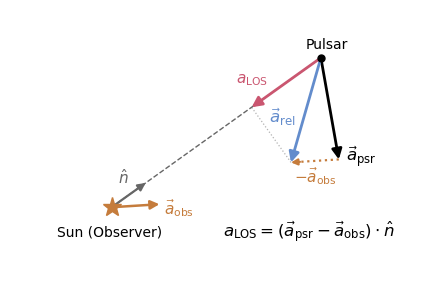

In [120]:
from matplotlib.patches import FancyArrowPatch

C_PSR, C_OBS, C_REL, C_LOS = "#ab62c0", "#c57c3c", "#638ccc", "#ca5670"
C_SIGHT = "0.4"

def arrow(ax, p0, p1, color, lw=2.0, style="-", mut=15):
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    if style != "-":  # dotted shaft + solid head
        u = (p1 - p0) / np.linalg.norm(p1 - p0)
        ax.plot(*zip(p0, p1 - 0.18 * u), ls=style, lw=lw, color=color, zorder=5)
        ax.add_patch(FancyArrowPatch(p1 - 0.3 * u, p1, arrowstyle="-|>",
                                     mutation_scale=mut, lw=lw, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))
    else:
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=mut,
                                     lw=lw, color=color, shrinkA=0, shrinkB=0, zorder=5))

fig, ax = plt.subplots(figsize=(5.4, 4.0), facecolor="white")

obs = np.array([0.0, 0.0])
psr = np.array([7.0, 5.0])
nhat = (psr - obs) / np.linalg.norm(psr - obs)

a_psr = np.array([0.6, -3.4])        # pulsar accel in the Galactic frame
a_obs = np.array([1.6, 0.1])        # observer (Sun) accel in the Galactic frame
a_rel = a_psr - a_obs                # what gravity imprints on the timing
a_los_vec = (a_rel @ nhat) * nhat    # the measured piece

ax.plot(*obs, marker="*", color=C_OBS, ms=14, zorder=6)
ax.text(obs[0] + 1.7, obs[1] - .85, "Sun (Observer)", fontsize=10, ha="right", va="center")
ax.plot(*psr, marker="o", color="k", ms=5, zorder=6)
ax.text(psr[0] - 0.5, psr[1] + 0.3, "Pulsar", fontsize=10)

ax.plot(*zip(obs, psr), ls="--", lw=1.0, color=C_SIGHT, zorder=2)
arrow(ax, obs + 0 * nhat, obs + 1.4 * nhat, C_SIGHT, lw=1.6, mut=11)
ax.text(*(1 * nhat + [-.6, .2]), r"$\hat{n}$", color=C_SIGHT, fontsize=11)

# observer's own acceleration, drawn at the observer
arrow(ax, obs, obs + a_obs, C_OBS, lw=1.8, mut=13)
ax.text(*(obs + a_obs + [0.15, -0.35]), r"$\vec{a}_{\rm obs}$", color=C_OBS, fontsize=11)

# construction at the pulsar: a_rel = a_psr + (-a_obs), tip to tail
arrow(ax, psr, psr + a_psr, color='black')
ax.text(*(psr + a_psr + [0.25, -0.1]), r"$\vec{a}_{\rm psr}$", color='black', fontsize=12)
arrow(ax, psr + a_psr, psr + a_psr - a_obs, C_OBS, lw=1.6, style=":", mut=9)
ax.text(*(psr + a_psr - 0.5 * a_obs + [0.0, -0.7]), r"$-\vec{a}_{\rm obs}$",
        color=C_OBS, fontsize=11, ha="center")
arrow(ax, psr, psr + a_rel, C_REL)
ax.text(*(psr + 0.55 * a_rel + [-.75, -0.25]), r"$\vec{a}_{\rm rel}$",
        color=C_REL, fontsize=12, ha="center")

# the measured projection, along the sight line
arrow(ax, psr, psr + a_los_vec, C_LOS)
ax.text(*(psr + a_los_vec + [0, 0.8]), r"$a_{\rm LOS}$",
        color=C_LOS, fontsize=11, ha="center")
ax.plot(*zip(psr + a_rel, psr + a_los_vec), ls=":", lw=0.9, color="0.7", zorder=1)

ax.text(6.6, -1, r"$a_{\rm LOS} = (\vec{a}_{\rm psr} - \vec{a}_{\rm obs})\cdot\hat{n}$",
        fontsize=12, ha="center")

ax.set_xlim(-3.4, 10.6); ax.set_ylim(-2.2, 6.6)
ax.set_aspect("equal"); ax.set_axis_off()
fig.savefig("../../../accelerations-paper/figures/rel_accel.pdf", bbox_inches="tight")


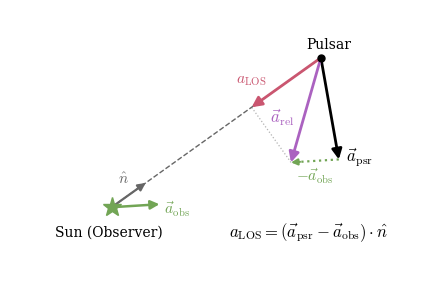

In [122]:
import scienceplots  # noqa: F401
from matplotlib.patches import FancyArrowPatch

# C_PSR, C_OBS, C_REL, C_LOS = "#ab62c0", "#c57c3c", "#638ccc", "#ca5670"
C_PSR, C_OBS, C_REL, C_LOS = "black", "#72a555", "#ab62c0", "#ca5670"

C_SIGHT = "0.4"

def arrow(ax, p0, p1, color, lw=2.0, style="-", mut=15):
    p0, p1 = np.asarray(p0, float), np.asarray(p1, float)
    if style != "-":  # dotted shaft + solid head
        u = (p1 - p0) / np.linalg.norm(p1 - p0)
        ax.plot(*zip(p0, p1 - 0.18 * u), ls=style, lw=lw, color=color, zorder=5)
        ax.add_patch(FancyArrowPatch(p1 - 0.3 * u, p1, arrowstyle="-|>",
                                     mutation_scale=mut, lw=lw, color=color,
                                     shrinkA=0, shrinkB=0, zorder=5))
    else:
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=mut,
                                     lw=lw, color=color, shrinkA=0, shrinkB=0, zorder=5))

with plt.style.context(["science", "no-latex"]):
    fig, ax = plt.subplots(figsize=(5.4, 4.0), facecolor="white")

    obs = np.array([0.0, 0.0])
    psr = np.array([7.0, 5.0])
    nhat = (psr - obs) / np.linalg.norm(psr - obs)

    a_psr = np.array([0.6, -3.4])        # pulsar accel in the Galactic frame
    a_obs = np.array([1.6, 0.1])         # observer (Sun) accel in the Galactic frame
    a_rel = a_psr - a_obs                # what gravity imprints on the timing
    a_los_vec = (a_rel @ nhat) * nhat    # the measured piece

    ax.plot(*obs, marker="*", color=C_OBS, ms=14, zorder=6)
    ax.text(obs[0] + 1.7, obs[1] - .85, "Sun (Observer)", fontsize=10, ha="right", va="center")
    ax.plot(*psr, marker="o", color="k", ms=5, zorder=6)
    ax.text(psr[0] - 0.5, psr[1] + 0.3, "Pulsar", fontsize=10)

    ax.plot(*zip(obs, psr), ls="--", lw=1.0, color=C_SIGHT, zorder=2)
    arrow(ax, obs + 0 * nhat, obs + 1.4 * nhat, C_SIGHT, lw=1.6, mut=11)
    ax.text(*(1 * nhat + [-.6, .2]), r"$\hat{n}$", color=C_SIGHT, fontsize=11)

    arrow(ax, obs, obs + a_obs, C_OBS, lw=1.8, mut=13)
    ax.text(*(obs + a_obs + [0.15, -0.35]), r"$\vec{a}_{\rm obs}$", color=C_OBS, fontsize=11)

    arrow(ax, psr, psr + a_psr, color="black")
    ax.text(*(psr + a_psr + [0.25, -0.1]), r"$\vec{a}_{\rm psr}$", color="black", fontsize=12)
    arrow(ax, psr + a_psr, psr + a_psr - a_obs, C_OBS, lw=1.6, style=":", mut=9)
    ax.text(*(psr + a_psr - 0.5 * a_obs + [0.0, -0.7]), r"$-\vec{a}_{\rm obs}$",
            color=C_OBS, fontsize=11, ha="center")
    arrow(ax, psr, psr + a_rel, C_REL)
    ax.text(*(psr + 0.55 * a_rel + [-.75, -0.25]), r"$\vec{a}_{\rm rel}$",
            color=C_REL, fontsize=12, ha="center")

    arrow(ax, psr, psr + a_los_vec, C_LOS)
    ax.text(*(psr + a_los_vec + [0, 0.8]), r"$a_{\rm LOS}$",
            color=C_LOS, fontsize=11, ha="center")
    ax.plot(*zip(psr + a_rel, psr + a_los_vec), ls=":", lw=0.9, color="0.7", zorder=1)

    ax.text(6.6, -1, r"$a_{\rm LOS} = (\vec{a}_{\rm psr} - \vec{a}_{\rm obs})\cdot\hat{n}$",
            fontsize=12, ha="center")

    ax.set_xlim(-3.4, 10.6); ax.set_ylim(-2.2, 6.6)
    ax.set_aspect("equal"); ax.set_axis_off()
    fig.savefig("../../../accelerations-paper/figures/rel_accel.pdf", bbox_inches="tight")
